In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./Data/aug_train.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [4]:
df = df.drop("city",axis=1)
df.head()

,enrollee_id,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


Handling Missing Values

In [5]:
df.isna().sum()

enrollee_id                  0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [6]:
##for gender, replace with mode.
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["gender"].head(),df["gender"].isna().sum()

(0    Male
 1    Male
 2    Male
 3    Male
 4    Male
 Name: gender, dtype: object,
 0)

In [7]:
df["enrolled_university"].unique()

array(['no_enrollment', 'Full time course', nan, 'Part time course'],
      dtype=object)

In [8]:
df["enrolled_university"] = df["enrolled_university"].fillna(df["enrolled_university"].mode()[0])
df["enrolled_university"].head(),df["enrolled_university"].isna().sum()

(0       no_enrollment
 1       no_enrollment
 2    Full time course
 3       no_enrollment
 4       no_enrollment
 Name: enrolled_university, dtype: object,
 0)

In [9]:
df["education_level"].unique()

array(['Graduate', 'Masters', 'High School', nan, 'Phd', 'Primary School'],
      dtype=object)

In [10]:
df["education_level"] = df["education_level"].fillna(df["education_level"].mode()[0])
df["education_level"].head(),df["education_level"].isna().sum()

(0    Graduate
 1    Graduate
 2    Graduate
 3    Graduate
 4     Masters
 Name: education_level, dtype: object,
 0)

In [11]:
df["major_discipline"] = df["major_discipline"].fillna(df["major_discipline"].mode()[0])
df["major_discipline"].head(),df["major_discipline"].isna().sum()

(0               STEM
 1               STEM
 2               STEM
 3    Business Degree
 4               STEM
 Name: major_discipline, dtype: object,
 0)

In [12]:
df["experience"].unique()


array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', nan],
      dtype=object)

In [13]:
df["experience"] = df["experience"].replace('>20','21')
df["experience"] = df["experience"].replace('<1','0')
df["experience"].unique()

array(['21', '15', '5', '0', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', nan],
      dtype=object)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city_development_index  19158 non-null  float64
 2   gender                  19158 non-null  object 
 3   relevent_experience     19158 non-null  object 
 4   enrolled_university     19158 non-null  object 
 5   education_level         19158 non-null  object 
 6   major_discipline        19158 non-null  object 
 7   experience              19093 non-null  object 
 8   company_size            13220 non-null  object 
 9   company_type            13018 non-null  object 
 10  last_new_job            18735 non-null  object 
 11  training_hours          19158 non-null  int64  
 12  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(9)
memory usage: 1.9+ MB


In [15]:
df["experience"] = df["experience"].astype(float)
df["experience"].unique()

array([21., 15.,  5.,  0., 11., 13.,  7., 17.,  2., 16.,  1.,  4., 10.,
       14., 18., 19., 12.,  3.,  6.,  9.,  8., 20., nan])

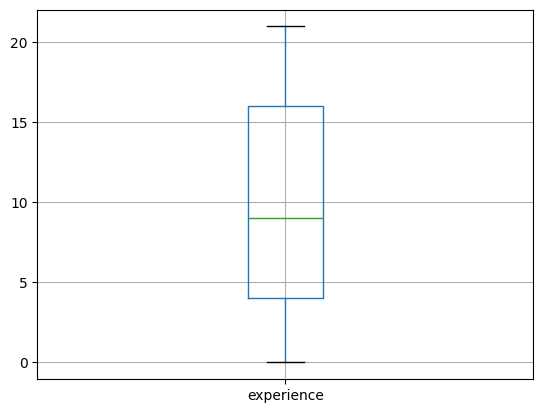

In [16]:
import matplotlib.pyplot as plt
temp = pd.DataFrame(df["experience"])
temp.boxplot()
plt.show()

In [17]:
df["experience"] = df["experience"].fillna(df["experience"].mean())
df["experience"].head(),df["experience"].unique()

(0    21.0
 1    15.0
 2     5.0
 3     0.0
 4    21.0
 Name: experience, dtype: float64,
 array([21.        , 15.        ,  5.        ,  0.        , 11.        ,
        13.        ,  7.        , 17.        ,  2.        , 16.        ,
         1.        ,  4.        , 10.        , 14.        , 18.        ,
        19.        , 12.        ,  3.        ,  6.        ,  9.        ,
         8.        , 20.        , 10.10014141]))

In [18]:
df["company_size"].unique()

array([nan, '50-99', '<10', '10000+', '5000-9999', '1000-4999', '10/49',
       '100-500', '500-999'], dtype=object)

In [19]:
df["company_size"] = df["company_size"].replace('<10','0-10')
df["company_size"] = df["company_size"].replace('10/49','10-49')
df["company_size"].unique()

array([nan, '50-99', '0-10', '10000+', '5000-9999', '1000-4999', '10-49',
       '100-500', '500-999'], dtype=object)

In [20]:
df["company_size"] = df["company_size"].fillna(df["company_size"].mode()[0])
df["company_size"].head()

0    50-99
1    50-99
2    50-99
3    50-99
4    50-99
Name: company_size, dtype: object

In [21]:
df["company_size"].unique()

array(['50-99', '0-10', '10000+', '5000-9999', '1000-4999', '10-49',
       '100-500', '500-999'], dtype=object)

In [22]:
df["company_type"].unique()

array([nan, 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup', 'Other',
       'Public Sector', 'NGO'], dtype=object)

In [23]:
df["company_type"] = df["company_type"].fillna(df["company_type"].mode()[0])
df["company_type"].head(),df["company_type"].isna().sum()

(0           Pvt Ltd
 1           Pvt Ltd
 2           Pvt Ltd
 3           Pvt Ltd
 4    Funded Startup
 Name: company_type, dtype: object,
 0)

In [24]:
df["last_new_job"].unique()

array(['1', '>4', 'never', '4', '3', '2', nan], dtype=object)

In [25]:
df["last_new_job"] = df["last_new_job"].replace('>4','5')
df["last_new_job"] = df["last_new_job"].replace('never','0')
df["last_new_job"] = df["last_new_job"].astype(float)
df["last_new_job"].unique()

array([ 1.,  5.,  0.,  4.,  3.,  2., nan])

In [26]:
df["last_new_job"] = df["last_new_job"].fillna(df["last_new_job"].median())
df["last_new_job"].unique()

array([1., 5., 0., 4., 3., 2.])

In [27]:
df["training_hours"].unique()

array([ 36,  47,  83,  52,   8,  24,  18,  46, 123,  32, 108,  23,  26,
       106,   7, 132,  68,  50,  48,  65,  13,  22, 148,  72,  40, 141,
        82, 145, 206, 152,  42,  14, 112,  87,  20,  21,  92, 102,  43,
        45,  19,  90,  25,  15,  98, 142,  28, 228,  29,  12,  17,  35,
         4, 136,  27,  74,  86,  75, 332, 140, 182, 172,  33,  34, 150,
       160,   3,   2, 210, 101,  59, 260, 131, 109,  70,  51,  60, 164,
       290, 133,  76, 156, 120, 100,  39,  55,  49,   6, 125, 326, 198,
        11,  41, 114, 246,  81,  31,  84, 105,  38, 178, 104, 202,  88,
       218,  62,  10,  80,  77,  37, 162, 190,  30,  16,   5,  54,  44,
       110, 262, 107, 134, 103,  96,  57, 240,  94, 113,  56,  64, 320,
         9, 129,  58, 126, 166,  95,  97, 204, 116, 161, 146, 302,  53,
       143, 124, 214, 288, 306, 322,  67,  61, 130, 220,  78, 314, 226,
       280,  91, 234, 163, 151,  85, 256, 168, 144,  66, 128,  73, 122,
       154,  63, 292, 188,  71, 135, 138, 184,  89, 157, 118, 11

In [28]:
df["training_hours"].isna().sum()

0

Outlier Analysis

In [29]:
sorted = list(df["training_hours"])
sorted.sort()

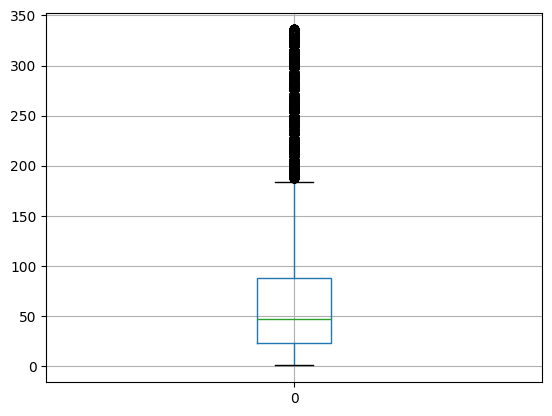

In [30]:
pd.DataFrame(sorted).boxplot()
plt.show()

In [31]:
q1_term = 0.25*len(sorted)+1
q3_term = 0.75*len(sorted)+1
q1_term,q3_term

(4790.5, 14369.5)

In [32]:
q1_decimal = q1_term - int(q1_term)
q1_decimal

0.5

In [33]:
q1_part1 = sorted[int(q1_term)+1]
q1_part1

23

In [34]:
q1_part2 = q1_decimal*(sorted[int(q1_term)+1+1] - sorted[int(q1_term)+1])
q1_part2

0.0

In [35]:
q1 = q1_part1 + q1_part2
q1

23.0

In [36]:
q3_decimal = q3_term - int(q3_term)
q3_decimal

0.5

In [37]:
q3_part1 = sorted[int(q3_term)+1]
q3_part1

88

In [38]:
q3_part2 = q3_decimal*(sorted[int(q3_term)+1+1] - sorted[int(q3_term)+1])
q3_part2

0.0

In [39]:
q3 = q3_part1 + q3_part2
q3

88.0

In [40]:
iqr = q3-q1
iqr

65.0

In [41]:
min = q1 - iqr
min

-42.0

In [42]:
max = q3+iqr
max

153.0

In [43]:
##so outliers are at the upper end

In [44]:
df["training_hours"].describe()

count    19158.000000
mean        65.366896
std         60.058462
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

In [45]:
###95th percentile
q95_term = 0.92*len(sorted)+1
q95_term

17626.36

In [46]:
q95_decimal = q95_term - int(q95_term)
q95_decimal

0.3600000000005821

In [47]:
q95_part1 = sorted[int(q95_term)+1]
q95_part1

158

In [48]:
q95_part2 = q95_decimal*(sorted[int(q95_term)+1+1] - sorted[int(q95_term)+1])
q95_part2

0.0

In [49]:
q95 = q95_part1 + q95_part2
q95

158.0

In [50]:
df["training_hours"][df["training_hours"]>=q95]

35       206
69       228
89       332
91       182
93       172
        ... 
19107    322
19114    160
19117    214
19118    316
19145    190
Name: training_hours, Length: 1546, dtype: int64

In [51]:
df.loc[df['training_hours'] >= max, 'training_hours'] = q95
df["training_hours"].max()

158

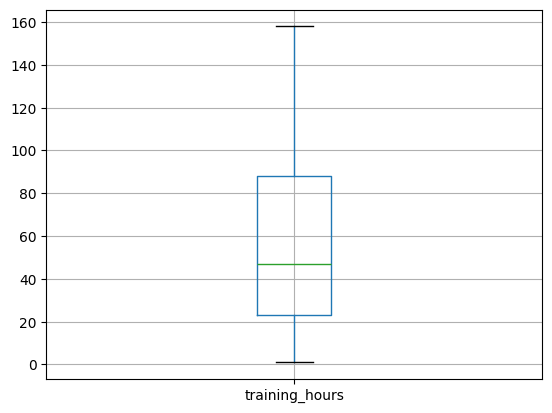

In [52]:
pd.DataFrame(df["training_hours"]).boxplot()
plt.show()

In [53]:
df["training_hours"].skew()

0.8404856267981223

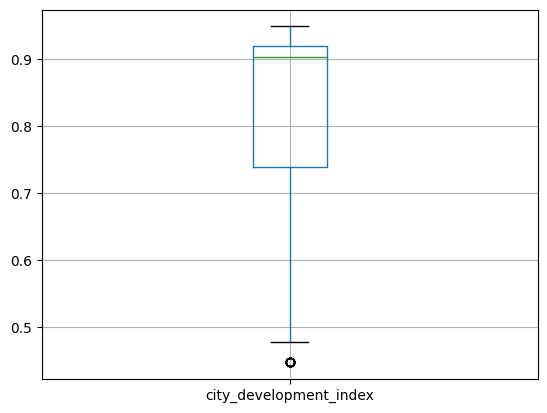

In [54]:
pd.DataFrame(df["city_development_index"]).boxplot()
plt.show()

In [55]:
iqr = df["city_development_index"].describe()["75%"]-df["city_development_index"].describe()["25%"]
iqr

0.18000000000000005

In [56]:
min = df["city_development_index"].describe()["25%"]-iqr
max = df["city_development_index"].describe()["75%"]+iqr

In [57]:
min,max

(0.5599999999999999, 1.1)

In [58]:
df["city_development_index"][df["city_development_index"]<min].count()

577

In [59]:
df["city_development_index"][df["city_development_index"]>max].count()

0

In [60]:
sorted = list(df["city_development_index"])
sorted.sort()
sorted

[0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.4479999999999999,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.479,
 0.487,
 0.487,
 0.487,
 0.487,
 0.487,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.493,
 0.512,
 0.512,
 0.512,
 0.512,
 0.512,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.516,
 0.518,
 0.518,
 0.518,
 0.518,
 0.518,
 0.518,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.527,
 0.

In [61]:
q_5 = 0.05*len(sorted)+1
q_95 = 0.95*len(sorted)+1
q_5,q_95

(958.9000000000001, 18201.1)

In [62]:
decimal = q_5 - int(q_5)
decimal

0.900000000000091

In [63]:
q_5_part1 = sorted[int(q_5)+1]
q_5_part1

0.624

In [64]:
q_5_part2 = decimal*(sorted[int(q_5_part1)+1+1]-sorted[int(q_5_part1)+1])
q_5_part2

0.0

In [65]:
q_5val = q_5_part1+q_5_part2
q_5val

0.624

In [66]:
decimal = q_95 - int(q_95)
decimal

0.09999999999854481

In [67]:
q_95_part1 = sorted[int(q_95)+1]
q_95_part1

0.926

In [68]:
q_95_part2 = decimal*(sorted[int(q_95_part1)+1+1]-sorted[int(q_95_part1)+1])
q_95_part2

0.0

In [69]:
q_95val = q_95_part1+q_95_part2
q_95val

0.926

In [70]:
df.loc[df['city_development_index'] <= min, 'city_development_index'] = q_5
df.loc[df['city_development_index'] >= max, 'city_development_index'] = q_95
df["city_development_index"].unique()

array([9.20000e-01, 7.76000e-01, 6.24000e-01, 7.89000e-01, 7.67000e-01,
       7.64000e-01, 7.62000e-01, 9.13000e-01, 9.26000e-01, 8.27000e-01,
       8.43000e-01, 8.04000e-01, 8.55000e-01, 8.87000e-01, 9.10000e-01,
       8.84000e-01, 9.24000e-01, 6.66000e-01, 1.82011e+04, 9.23000e-01,
       7.94000e-01, 7.54000e-01, 9.39000e-01, 8.65000e-01, 6.98000e-01,
       8.93000e-01, 7.96000e-01, 8.66000e-01, 6.82000e-01, 8.02000e-01,
       5.79000e-01, 8.78000e-01, 8.97000e-01, 9.49000e-01, 9.25000e-01,
       8.96000e-01, 8.36000e-01, 6.93000e-01, 7.69000e-01, 7.75000e-01,
       9.03000e-01, 7.27000e-01, 6.40000e-01, 7.43000e-01, 8.99000e-01,
       9.15000e-01, 6.89000e-01, 8.95000e-01, 8.90000e-01, 8.47000e-01,
       7.66000e-01, 7.38000e-01, 6.47000e-01, 7.95000e-01, 7.40000e-01,
       7.01000e-01, 8.40000e-01, 6.91000e-01, 7.35000e-01, 7.42000e-01,
       7.22000e-01, 9.21000e-01, 8.48000e-01, 8.56000e-01, 8.98000e-01,
       8.30000e-01, 7.30000e-01, 6.80000e-01, 7.25000e-01, 7.630

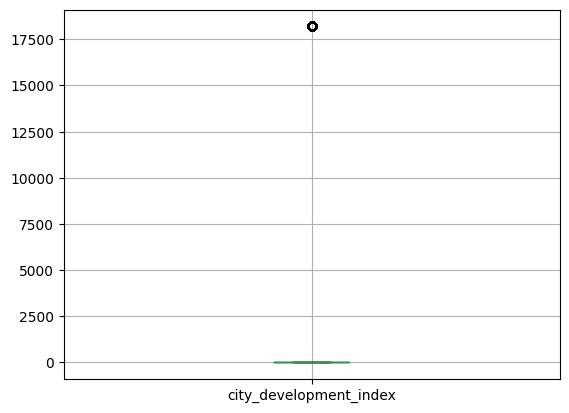

In [71]:
pd.DataFrame(df["city_development_index"]).boxplot()
plt.show()

In [72]:
df.head()

,enrollee_id,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,50-99,Pvt Ltd,1.0,36,1.0
1,29725,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,5.0,47,0.0
2,11561,0.624,Male,No relevent experience,Full time course,Graduate,STEM,5.0,50-99,Pvt Ltd,0.0,83,0.0
3,33241,0.789,Male,No relevent experience,no_enrollment,Graduate,Business Degree,0.0,50-99,Pvt Ltd,0.0,52,1.0
4,666,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,50-99,Funded Startup,4.0,8,0.0


In [73]:
df["gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [74]:
df = pd.get_dummies(df,columns=["gender","major_discipline","company_type"],drop_first=False,dtype=int)
df.head()

,enrollee_id,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,target,...,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,8949,0.920,Has relevent experience,no_enrollment,Graduate,21.0,50-99,1.0,36,1.0,...,0,0,0,1,0,0,0,0,0,1
1,29725,0.776,No relevent experience,no_enrollment,Graduate,15.0,50-99,5.0,47,0.0,...,0,0,0,1,0,0,0,0,0,1
2,11561,0.624,No relevent experience,Full time course,Graduate,5.0,50-99,0.0,83,0.0,...,0,0,0,1,0,0,0,0,0,1
3,33241,0.789,No relevent experience,no_enrollment,Graduate,0.0,50-99,0.0,52,1.0,...,0,0,0,0,0,0,0,0,0,1
4,666,0.767,Has relevent experience,no_enrollment,Masters,21.0,50-99,4.0,8,0.0,...,0,0,0,1,0,1,0,0,0,0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   enrollee_id                       19158 non-null  int64  
 1   city_development_index            19158 non-null  float64
 2   relevent_experience               19158 non-null  object 
 3   enrolled_university               19158 non-null  object 
 4   education_level                   19158 non-null  object 
 5   experience                        19158 non-null  float64
 6   company_size                      19158 non-null  object 
 7   last_new_job                      19158 non-null  float64
 8   training_hours                    19158 non-null  int64  
 9   target                            19158 non-null  float64
 10  gender_Female                     19158 non-null  int32  
 11  gender_Male                       19158 non-null  int32  
 12  gend

In [76]:
values = df["company_size"].unique()
values

array(['50-99', '0-10', '10000+', '5000-9999', '1000-4999', '10-49',
       '100-500', '500-999'], dtype=object)

In [77]:
labels = [2,0,7,6,5,1,3,4]
values,labels

(array(['50-99', '0-10', '10000+', '5000-9999', '1000-4999', '10-49',
        '100-500', '500-999'], dtype=object),
 [2, 0, 7, 6, 5, 1, 3, 4])

In [78]:
df["company_size"] = df["company_size"].replace(values,labels)
df["company_size"].unique()

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_76520\2256779259.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["company_size"] = df["company_size"].replace(values,labels)


array([2, 0, 7, 6, 5, 1, 3, 4], dtype=int64)

In [79]:
values = df["relevent_experience"].unique()

In [80]:
labels = [1,0]
values,labels

(array(['Has relevent experience', 'No relevent experience'], dtype=object),
 [1, 0])

In [81]:
df["relevent_experience"] = df["relevent_experience"].replace(values,labels)
df["relevent_experience"].unique()

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_76520\1211771326.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["relevent_experience"] = df["relevent_experience"].replace(values,labels)


array([1, 0], dtype=int64)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   enrollee_id                       19158 non-null  int64  
 1   city_development_index            19158 non-null  float64
 2   relevent_experience               19158 non-null  int64  
 3   enrolled_university               19158 non-null  object 
 4   education_level                   19158 non-null  object 
 5   experience                        19158 non-null  float64
 6   company_size                      19158 non-null  int64  
 7   last_new_job                      19158 non-null  float64
 8   training_hours                    19158 non-null  int64  
 9   target                            19158 non-null  float64
 10  gender_Female                     19158 non-null  int32  
 11  gender_Male                       19158 non-null  int32  
 12  gend

In [83]:
values = df["enrolled_university"].unique()
values

array(['no_enrollment', 'Full time course', 'Part time course'],
      dtype=object)

In [84]:
labels = [0,2,1]

In [85]:
df["enrolled_university"] = df["enrolled_university"].replace(values,labels)
df["enrolled_university"].unique()

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_76520\2300801064.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["enrolled_university"] = df["enrolled_university"].replace(values,labels)


array([0, 2, 1], dtype=int64)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   enrollee_id                       19158 non-null  int64  
 1   city_development_index            19158 non-null  float64
 2   relevent_experience               19158 non-null  int64  
 3   enrolled_university               19158 non-null  int64  
 4   education_level                   19158 non-null  object 
 5   experience                        19158 non-null  float64
 6   company_size                      19158 non-null  int64  
 7   last_new_job                      19158 non-null  float64
 8   training_hours                    19158 non-null  int64  
 9   target                            19158 non-null  float64
 10  gender_Female                     19158 non-null  int32  
 11  gender_Male                       19158 non-null  int32  
 12  gend

In [87]:
df.head()

,enrollee_id,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,target,...,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,8949,0.920,1,0,Graduate,21.0,2,1.0,36,1.0,...,0,0,0,1,0,0,0,0,0,1
1,29725,0.776,0,0,Graduate,15.0,2,5.0,47,0.0,...,0,0,0,1,0,0,0,0,0,1
2,11561,0.624,0,2,Graduate,5.0,2,0.0,83,0.0,...,0,0,0,1,0,0,0,0,0,1
3,33241,0.789,0,0,Graduate,0.0,2,0.0,52,1.0,...,0,0,0,0,0,0,0,0,0,1
4,666,0.767,1,0,Masters,21.0,2,4.0,8,0.0,...,0,0,0,1,0,1,0,0,0,0


In [88]:
values = df["education_level"].unique()

In [89]:
values

array(['Graduate', 'Masters', 'High School', 'Phd', 'Primary School'],
      dtype=object)

In [90]:
labels = [2,3,1,4,0]
labels

[2, 3, 1, 4, 0]

In [91]:
df["education_level"] = df["education_level"].replace(values,labels)
df["education_level"].unique()

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_76520\3766738430.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["education_level"] = df["education_level"].replace(values,labels)


array([2, 3, 1, 4, 0], dtype=int64)

In [92]:
df.head()

,enrollee_id,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,target,...,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,8949,0.920,1,0,2,21.0,2,1.0,36,1.0,...,0,0,0,1,0,0,0,0,0,1
1,29725,0.776,0,0,2,15.0,2,5.0,47,0.0,...,0,0,0,1,0,0,0,0,0,1
2,11561,0.624,0,2,2,5.0,2,0.0,83,0.0,...,0,0,0,1,0,0,0,0,0,1
3,33241,0.789,0,0,2,0.0,2,0.0,52,1.0,...,0,0,0,0,0,0,0,0,0,1
4,666,0.767,1,0,3,21.0,2,4.0,8,0.0,...,0,0,0,1,0,1,0,0,0,0


In [93]:
columns = list(df.columns)
columns

['enrollee_id',
 'city_development_index',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'experience',
 'company_size',
 'last_new_job',
 'training_hours',
 'target',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'major_discipline_Arts',
 'major_discipline_Business Degree',
 'major_discipline_Humanities',
 'major_discipline_No Major',
 'major_discipline_Other',
 'major_discipline_STEM',
 'company_type_Early Stage Startup',
 'company_type_Funded Startup',
 'company_type_NGO',
 'company_type_Other',
 'company_type_Public Sector',
 'company_type_Pvt Ltd']

In [94]:
columns.remove("enrollee_id")
columns

['city_development_index',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'experience',
 'company_size',
 'last_new_job',
 'training_hours',
 'target',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'major_discipline_Arts',
 'major_discipline_Business Degree',
 'major_discipline_Humanities',
 'major_discipline_No Major',
 'major_discipline_Other',
 'major_discipline_STEM',
 'company_type_Early Stage Startup',
 'company_type_Funded Startup',
 'company_type_NGO',
 'company_type_Other',
 'company_type_Public Sector',
 'company_type_Pvt Ltd']

In [95]:
columns.remove("target")

In [96]:
x = df.loc[:,columns]
y = df.loc[:,"target"]

In [97]:
x

,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,gender_Female,gender_Male,...,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,0.920,1,0,2,21.0,2,1.0,36,0,1,...,0,0,0,1,0,0,0,0,0,1
1,0.776,0,0,2,15.0,2,5.0,47,0,1,...,0,0,0,1,0,0,0,0,0,1
2,0.624,0,2,2,5.0,2,0.0,83,0,1,...,0,0,0,1,0,0,0,0,0,1
3,0.789,0,0,2,0.0,2,0.0,52,0,1,...,0,0,0,0,0,0,0,0,0,1
4,0.767,1,0,3,21.0,2,4.0,8,0,1,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,0.878,0,0,2,14.0,2,1.0,42,0,1,...,1,0,0,0,0,0,0,0,0,1
19154,0.920,1,0,2,14.0,2,4.0,52,0,1,...,0,0,0,1,0,0,0,0,0,1
19155,0.920,1,0,2,21.0,2,4.0,44,0,1,...,0,0,0,1,0,0,0,0,0,1
19156,0.802,1,0,1,0.0,4,2.0,97,0,1,...,0,0,0,1,0,0,0,0,0,1


In [98]:
y

0        1.0
1        0.0
2        0.0
3        1.0
4        0.0
        ... 
19153    1.0
19154    1.0
19155    0.0
19156    0.0
19157    0.0
Name: target, Length: 19158, dtype: float64

In [99]:
columns = x.columns
columns

Index(['city_development_index', 'relevent_experience', 'enrolled_university',
       'education_level', 'experience', 'company_size', 'last_new_job',
       'training_hours', 'gender_Female', 'gender_Male', 'gender_Other',
       'major_discipline_Arts', 'major_discipline_Business Degree',
       'major_discipline_Humanities', 'major_discipline_No Major',
       'major_discipline_Other', 'major_discipline_STEM',
       'company_type_Early Stage Startup', 'company_type_Funded Startup',
       'company_type_NGO', 'company_type_Other', 'company_type_Public Sector',
       'company_type_Pvt Ltd'],
      dtype='object')

In [100]:
for column in columns:
    min = x[column].min()
    max = x[column].max()
    den = max-min
    x[column] = (x[column]-min)/den
x.head()

,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,gender_Female,gender_Male,...,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,0.000020,1.0,0.0,0.50,1.000000,0.285714,0.2,0.222930,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000012,0.0,0.0,0.50,0.714286,0.285714,1.0,0.292994,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000003,0.0,1.0,0.50,0.238095,0.285714,0.0,0.522293,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000012,0.0,0.0,0.50,0.000000,0.285714,0.0,0.324841,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000011,1.0,0.0,0.75,1.000000,0.285714,0.8,0.044586,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [101]:
x.to_csv("preprocessed_Data.csv")
y.to_csv("target.csv")

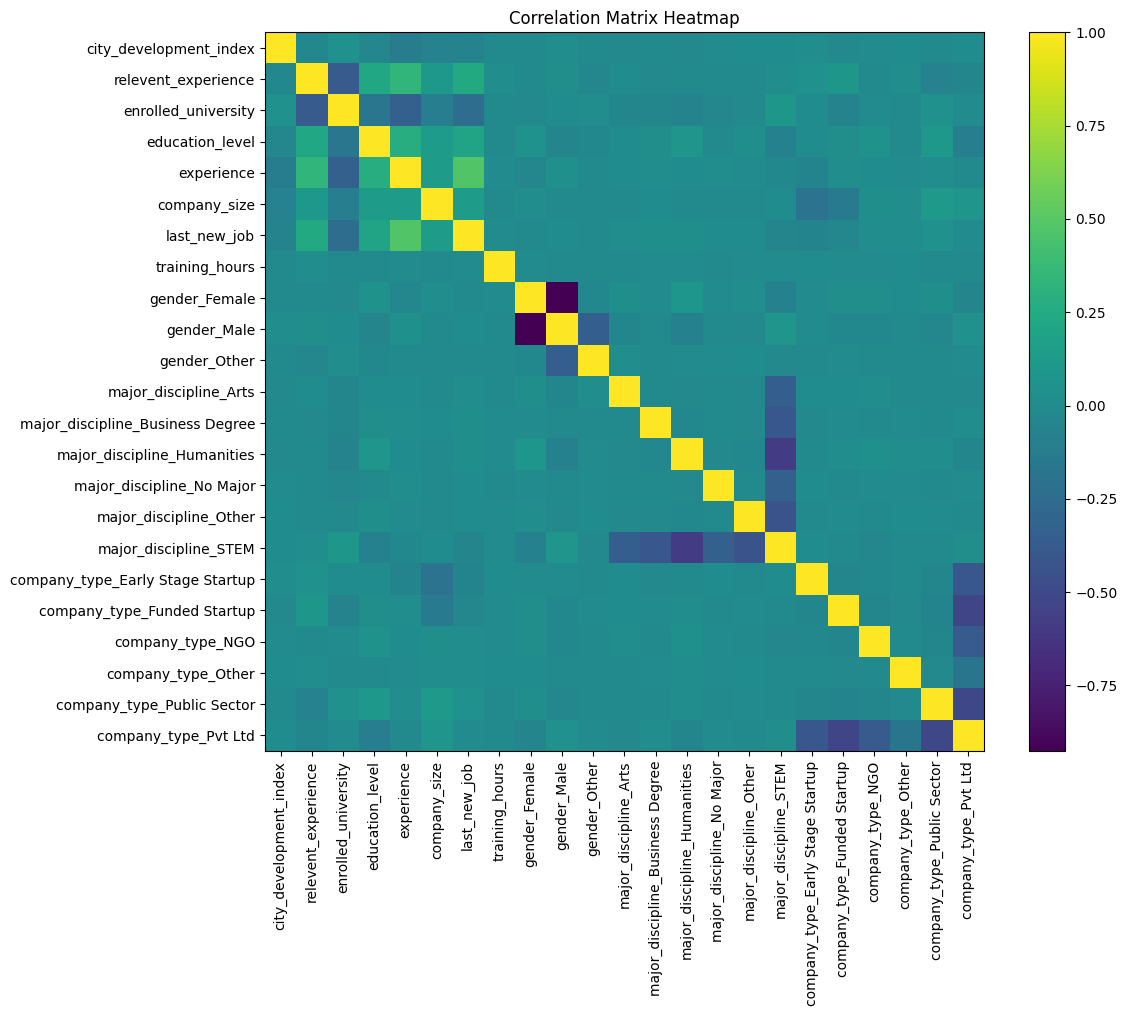

In [103]:
import matplotlib.pyplot as plt
import numpy as np

corr = x.corr()

plt.figure(figsize=(12, 10))

plt.imshow(corr, interpolation='nearest')
plt.colorbar()

# Add labels
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)

plt.title("Correlation Matrix Heatmap")

plt.tight_layout()
plt.show()